<a href="https://colab.research.google.com/github/sangramshitole07/AML/blob/main/Linear_Rigression_Using_Income_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [4]:
from google.colab import files
uploaded=files.upload()
dataset=pd.read_csv("income_data.csv")


Saving income_data.csv to income_data.csv


In [5]:
dataset.head()

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


In [7]:
print("Information about the dataset ", dataset.info())
print("Decription about dataset ",dataset.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  498 non-null    int64  
 1   income      498 non-null    float64
 2   happiness   498 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB
Information about the dataset  None
Decription about dataset         Unnamed: 0      income   happiness
count  498.000000  498.000000  498.000000
mean   249.500000    4.466902    3.392859
std    143.904482    1.737527    1.432813
min      1.000000    1.506275    0.266044
25%    125.250000    3.006256    2.265864
50%    249.500000    4.423710    3.472536
75%    373.750000    5.991913    4.502621
max    498.000000    7.481521    6.863388


In [8]:
print(dataset.columns)

Index(['Unnamed: 0', 'income', 'happiness'], dtype='object')


In [9]:
dataset.isnull().sum()

,0
Unnamed: 0,0
income,0
happiness,0


In [11]:
from sklearn.model_selection import train_test_split
X=dataset["income"]
y=dataset["happiness"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train.values.reshape(-1, 1),y_train)

LinearRegression()

In [14]:
print("Intercept ", model.intercept_)
print("Coefficient ", model.coef_)
print("Slop ", model.coef_[0])

Intercept  0.14170387227353531
Coefficient  [0.7247687]
Slop  0.7247687016076183


In [17]:
#coefficient table
coefficient_table=pd.DataFrame({"Feature ": [X.name], "Coefficient ":model.coef_})

In [18]:
coefficient_table

,Feature,Coefficient
0,income,0.724769


In [19]:
y_test

,happiness
487,4.754168
73,4.159609
231,2.295700
175,2.311554
237,2.861274
...,...
247,3.427723
383,3.835578
19,2.584729
321,2.842868


In [21]:
y_pred=model.predict(X_test.values.reshape(-1, 1))
y_pred

array([3.21752987, 2.21792257, 3.20280332, 1.79020704, 1.74394749,
       2.39018719, 4.44664262, 4.86010664, 1.89050708, 3.50456863,
       4.09833273, 2.4318678 , 2.85594355, 3.54519132, 2.78796716,
       1.80768864, 2.52124048, 5.16673969, 2.45094439, 3.996441  ,
       1.83486036, 2.72998006, 2.63135811, 1.23340488, 4.61112137,
       1.72884986, 2.46409207, 5.3782968 , 4.21884267, 4.12789401,
       1.34529138, 3.72063824, 2.83545189, 3.71043375, 4.0008309 ,
       4.01012804, 1.2713695 , 2.47646914, 1.31859325, 2.24910091,
       5.35598486, 4.42244764, 5.0893214 , 4.83614181, 2.94122983,
       2.15161714, 1.6263909 , 3.1687238 , 2.67722482, 1.46401227,
       4.0291672 , 2.98869745, 5.14038236, 3.7164133 , 3.58847209,
       3.3425148 , 3.54804131, 3.94616611, 4.93059286, 3.81954393,
       4.89818897, 1.55970378, 5.09603988, 2.34495858, 2.2134292 ,
       5.38998089, 4.72238072, 3.7692388 , 2.40771063, 5.32646295,
       4.52828042, 3.42736682, 3.04261746, 3.07258943, 1.94085

Text(0.5, 1.0, 'Actual vs Predicted Values')

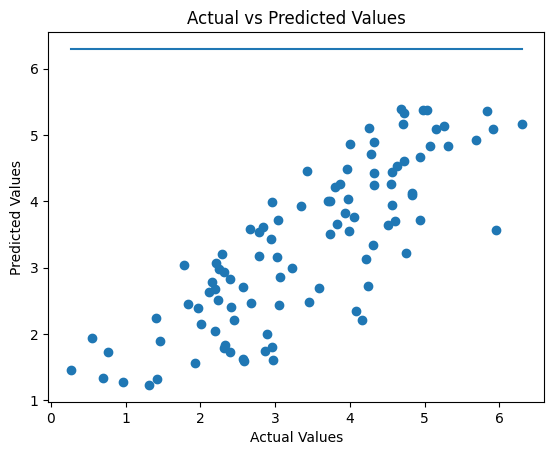

In [23]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
minimum= min(y_test.min(),y_pred.min())
maximum=max(y_test.max(),y_pred.max())
plt.plot([minimum,maximum],[maximum,maximum])
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

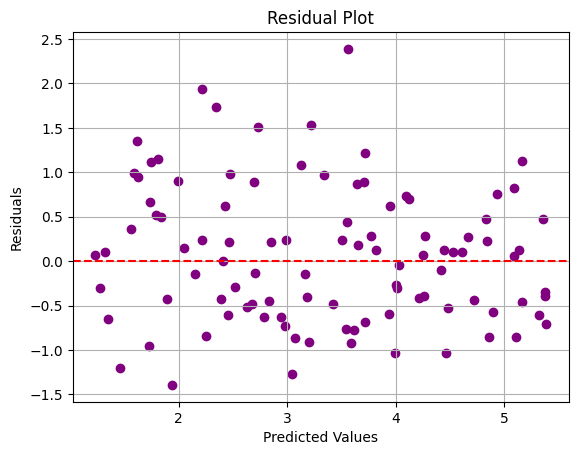

In [24]:


from matplotlib import lines
residual =y_test - y_pred
plt.scatter(y_pred,residual,color='purple')
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [26]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae )

Mean Squared Error: 0.590146394343082
R-squared: 0.6662585264303965
Mean Absolute Error: 0.6269683431894553
